In [1]:
import sys
!{sys.executable} -m pip install datasets transformers scikit-learn matplotlib accelerate

c:\Users\kiril\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Устройство: cpu

=== 1. Загрузка датасета и подготовка split ===


Обнаружен CPU: для ускорения обучения будут использованы ограниченные подвыборки train/validation/test.
Датасет: emotion
Число классов: 6
Размер train: 6000
Размер validation: 1000
Размер test: 2000
Классы: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

=== 2. Примеры данных ===
                                                                                                                        text  label_id label_name
                                                                                                while cycling in the country         4       fear
                                                                        i had pocket qq and was feeling pretty confident lol         1        joy
                                                                 i am in no way complaining or whining or feeling ungrateful         0    sadness
       i feel a bit stressed because it feels like im supposed to do something all the time and that i shoul

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6730.14it/s]


                                                                                   text predicted_label  score
                           i was feeling really troubled and down over what my dad said        NEGATIVE 0.9966
i feel so thrilled to have three such distinguished individuals such as yourselves here        POSITIVE 0.9998
        i feel is that the most likeable characters aren t important enough to the plot        NEGATIVE 0.9998
                                  I am very happy and excited about this wonderful day.        POSITIVE 0.9999
                                          I feel terrible, disappointed and really sad.        NEGATIVE 0.9995

Комментарий:
Готовая модель для SST-2 решает задачу sentiment analysis (POSITIVE/NEGATIVE),
а не многоклассовую emotion classification, поэтому её предсказания полезны только как предварительная демонстрация инференса,
но не как решение основной задачи HW13.

=== 5. Подготовка датасета для fine-tuning ===


...

Модель для fine-tuning: distilbert-base-uncased
max_length: 128
train batch size: 8
eval batch size: 8
epochs: 2
learning rate: 2e-05

=== 6. Обучение ===


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.722792,0.325310,0.897000,0.830743
2,0.217978,0.260700,0.920000,0.892930


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Обучение завершено.

=== 7. Финальная оценка на test (один раз) ===


test_accuracy = 0.9160
test_f1_macro = 0.8634

=== 8. Матрица ошибок ===


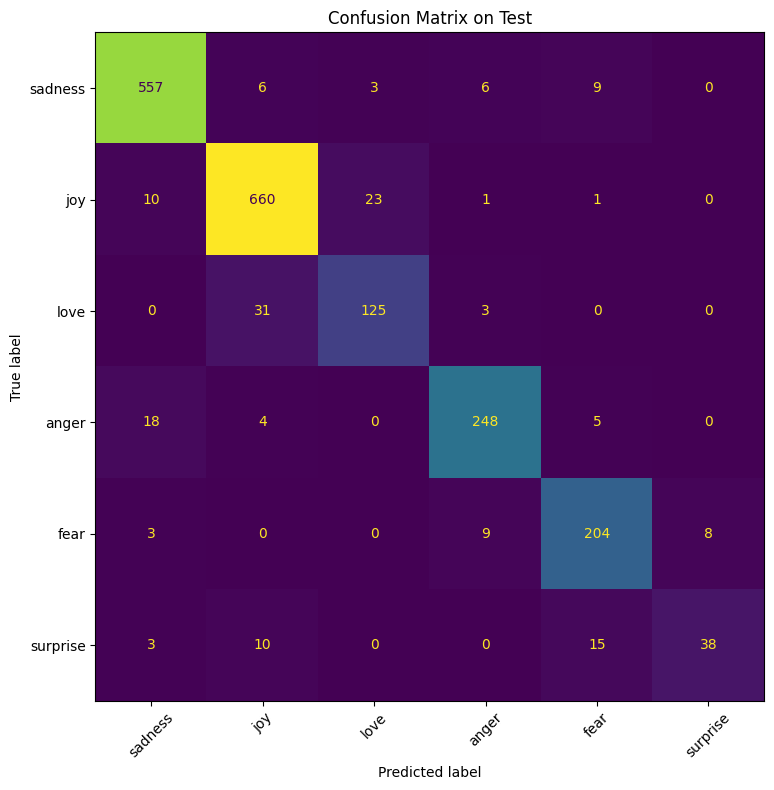

Матрица ошибок сохранена: c:\Users\kiril\OneDrive\Desktop\ИИИ\REP\III_2025-26\homeworks\HW13\artifacts\confusion_matrix.png

=== 9. Примеры предсказаний ===
                                                                                                                                                                                       text true_label pred_label  confidence
                                                                                                                               i was feeling really troubled and down over what my dad said    sadness    sadness      0.9936
                                                                                                    i feel so thrilled to have three such distinguished individuals such as yourselves here        joy        joy      0.9956
                                                                                                            i feel is that the most likeable characters aren t important enough t

In [2]:
import os
import random
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
    set_seed
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "HW13.ipynb").exists() or CURRENT_DIR.name == "HW13":
    BASE_DIR = CURRENT_DIR
elif (CURRENT_DIR / "homeworks" / "HW13").exists():
    BASE_DIR = CURRENT_DIR / "homeworks" / "HW13"
else:
    BASE_DIR = CURRENT_DIR

ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / "trainer_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "emotion"
BASE_MODEL_NAME = "distilbert-base-uncased"
INFERENCE_MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
MAX_LENGTH = 128
NUM_EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
TRAIN_BATCH_SIZE = 16 if torch.cuda.is_available() else 8
EVAL_BATCH_SIZE = 32 if torch.cuda.is_available() else 8

CPU_TRAIN_LIMIT = 6000
CPU_VALID_LIMIT = 1000
CPU_TEST_LIMIT = 2000

print("\n=== 1. Загрузка датасета и подготовка split ===")
raw_ds = load_dataset(DATASET_NAME)

if "validation" in raw_ds:
    ds = DatasetDict({
        "train": raw_ds["train"],
        "validation": raw_ds["validation"],
        "test": raw_ds["test"]
    })
else:
    split_1 = raw_ds["train"].train_test_split(test_size=0.2, seed=SEED)
    split_2 = split_1["test"].train_test_split(test_size=0.5, seed=SEED)
    ds = DatasetDict({
        "train": split_1["train"],
        "validation": split_2["train"],
        "test": split_2["test"]
    })

label_feature = ds["train"].features["label"]
id2label = {i: name for i, name in enumerate(label_feature.names)}
label2id = {name: i for i, name in id2label.items()}

if DEVICE.type == "cpu":
    print("Обнаружен CPU: для ускорения обучения будут использованы ограниченные подвыборки train/validation/test.")
    train_n = min(CPU_TRAIN_LIMIT, len(ds["train"]))
    val_n = min(CPU_VALID_LIMIT, len(ds["validation"]))
    test_n = min(CPU_TEST_LIMIT, len(ds["test"]))
    ds["train"] = ds["train"].shuffle(seed=SEED).select(range(train_n))
    ds["validation"] = ds["validation"].shuffle(seed=SEED).select(range(val_n))
    ds["test"] = ds["test"].shuffle(seed=SEED).select(range(test_n))

print(f"Датасет: {DATASET_NAME}")
print(f"Число классов: {len(id2label)}")
print(f"Размер train: {len(ds['train'])}")
print(f"Размер validation: {len(ds['validation'])}")
print(f"Размер test: {len(ds['test'])}")
print("Классы:", id2label)

print("\n=== 2. Примеры данных ===")
examples_df = pd.DataFrame({
    "text": [ds["train"][i]["text"] for i in range(min(5, len(ds["train"])))],
    "label_id": [ds["train"][i]["label"] for i in range(min(5, len(ds["train"])))],
    "label_name": [id2label[ds["train"][i]["label"]] for i in range(min(5, len(ds["train"])))]
})
print(examples_df.to_string(index=False))

print("\n=== 3. Токенизация: разбор нескольких примеров ===")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, use_fast=True)

token_examples = [
    ds["train"][0]["text"],
    ds["train"][1]["text"],
    ds["train"][2]["text"],
    "I am extremely happy because everything worked perfectly today.",
    "I feel nervous and a little scared about the result."
]

for idx, text in enumerate(token_examples[:5], 1):
    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=20,
        return_attention_mask=True
    )
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    print(f"\n--- Пример токенизации {idx} ---")
    print("Текст:", text)
    print("Токены:", tokens)
    print("input_ids:", encoded["input_ids"])
    print("attention_mask:", encoded["attention_mask"])

print("\nSpecial tokens токенизатора:")
print("CLS:", tokenizer.cls_token, tokenizer.cls_token_id)
print("SEP:", tokenizer.sep_token, tokenizer.sep_token_id)
print("PAD:", tokenizer.pad_token, tokenizer.pad_token_id)
print("UNK:", tokenizer.unk_token, tokenizer.unk_token_id)
print("MASK:", tokenizer.mask_token, tokenizer.mask_token_id)

print("\n=== 4. Инференс готовой pretrained модели ===")
clf = pipeline(
    "text-classification",
    model=INFERENCE_MODEL_NAME,
    tokenizer=INFERENCE_MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1
)

inference_texts = [
    ds["test"][0]["text"],
    ds["test"][1]["text"],
    ds["test"][2]["text"],
    "I am very happy and excited about this wonderful day.",
    "I feel terrible, disappointed and really sad."
]
inference_results = clf(inference_texts)

inference_rows = []
for text, pred in zip(inference_texts, inference_results):
    inference_rows.append({
        "text": text,
        "predicted_label": pred["label"],
        "score": round(float(pred["score"]), 4)
    })
print(pd.DataFrame(inference_rows).to_string(index=False))

print("\nКомментарий:")
print("Готовая модель для SST-2 решает задачу sentiment analysis (POSITIVE/NEGATIVE),")
print("а не многоклассовую emotion classification, поэтому её предсказания полезны только как предварительная демонстрация инференса,")
print("но не как решение основной задачи HW13.")

print("\n=== 5. Подготовка датасета для fine-tuning ===")
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

tokenized_ds = ds.map(tokenize_batch, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["text"])
tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format(type="torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {
        "accuracy": acc,
        "f1_macro": f1
    }

print(f"Модель для fine-tuning: {BASE_MODEL_NAME}")
print(f"max_length: {MAX_LENGTH}")
print(f"train batch size: {TRAIN_BATCH_SIZE}")
print(f"eval batch size: {EVAL_BATCH_SIZE}")
print(f"epochs: {NUM_EPOCHS}")
print(f"learning rate: {LEARNING_RATE}")

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available()
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("\n=== 6. Обучение ===")
train_result = trainer.train()
print("Обучение завершено.")

print("\n=== 7. Финальная оценка на test (один раз) ===")
test_predictions = trainer.predict(tokenized_ds["test"])
test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids
test_preds = np.argmax(test_logits, axis=-1)
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_confidences = test_probs.max(axis=1)

test_accuracy = accuracy_score(test_labels, test_preds)
test_f1_macro = f1_score(test_labels, test_preds, average="macro")

print(f"test_accuracy = {test_accuracy:.4f}")
print(f"test_f1_macro = {test_f1_macro:.4f}")

print("\n=== 8. Матрица ошибок ===")
cm = confusion_matrix(test_labels, test_preds, labels=list(range(len(id2label))))
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in range(len(id2label))])
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix on Test")
plt.tight_layout()
cm_path = ARTIFACTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Матрица ошибок сохранена: {cm_path}")

print("\n=== 9. Примеры предсказаний ===")
raw_test_texts = ds["test"]["text"]
sample_count = min(10, len(raw_test_texts))
sample_df = pd.DataFrame({
    "text": raw_test_texts[:sample_count],
    "true_label": [id2label[int(x)] for x in test_labels[:sample_count]],
    "pred_label": [id2label[int(x)] for x in test_preds[:sample_count]],
    "confidence": [round(float(x), 4) for x in test_confidences[:sample_count]]
})
print(sample_df.to_string(index=False))

full_predictions_df = pd.DataFrame({
    "text": raw_test_texts,
    "true_label": [id2label[int(x)] for x in test_labels],
    "pred_label": [id2label[int(x)] for x in test_preds],
    "confidence": [round(float(x), 6) for x in test_confidences]
})
preds_path = ARTIFACTS_DIR / "sample_predictions.csv"
full_predictions_df.to_csv(preds_path, index=False, encoding="utf-8")
print(f"\nФайл предсказаний сохранён: {preds_path}")

print("\n=== 10. Краткий анализ ошибок ===")
errors_df = full_predictions_df[full_predictions_df["true_label"] != full_predictions_df["pred_label"]].copy()
if len(errors_df) == 0:
    print("На выбранной test-части ошибок не найдено.")
else:
    print(errors_df.head(10).to_string(index=False))

print("\n=== 11. Итоговая сводка для report.md ===")
summary = {
    "dataset": DATASET_NAME,
    "num_classes": len(id2label),
    "train_size": len(ds["train"]),
    "validation_size": len(ds["validation"]),
    "test_size": len(ds["test"]),
    "base_model_for_finetuning": BASE_MODEL_NAME,
    "pretrained_inference_model": INFERENCE_MODEL_NAME,
    "max_length": MAX_LENGTH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "seed": SEED,
    "device": str(DEVICE),
    "test_accuracy": round(float(test_accuracy), 6),
    "test_f1_macro": round(float(test_f1_macro), 6),
    "artifacts": {
        "sample_predictions_csv": str(preds_path),
        "confusion_matrix_png": str(cm_path)
    }
}
print(json.dumps(summary, ensure_ascii=False, indent=2))

summary_path = ARTIFACTS_DIR / "run_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"\nДополнительная сводка сохранена: {summary_path}")
